### **Assignment Setup**
* Import Libraries
* Load Data
* Verify/Preview data

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Week 5 Exercise: Riemann Sum Function**

A Riemann sum is an estimation of the area under a curve using rectangles.

The right Riemann sum $R_{n}$ of a function $f$ on the interval $[a, b]$ with $n$ rectangles is calculated by

$$R_{n}=f(a+\Delta x)\Delta x+f(a+2\Delta x)\Delta x+\cdot\cdot\cdot+f(a+n\Delta x)\Delta x=\sum_{k=1}^{n}f(a+k\Delta x)\Delta x$$

where $\Delta x=\frac{b-a}{n}$ is the width of the rectangles.

Write a Python function to take in a mathematical function $f$, two interval endpoints $a$ and $b$, and the number of rectangles $n$, and then outputs the right Riemann sum $R_{n}$.



In [2]:
# ---------------------------------------------------------
# DEFINE RIGHT RIEMANN SUM FUNCTION
# ---------------------------------------------------------
# This function approximates the area under a curve by
# breaking it into rectangles and summing their areas.
# We use RIGHT endpoints (top-right corner of each rectangle).

def right_riemann_sum(func, a, b, n):
    """
    Approximate the area under a curve using a right Riemann sum.

    Parameters:
        func (function): the function f(x)
        a (float): start of interval
        b (float): end of interval
        n (int): number of rectangles

    Returns:
        float: estimated area under the curve
    """

    # Width of each rectangle
    delta_x = (b - a) / n

    # Initialize total area
    total_area = 0

    # Loop through each rectangle
    for k in range(1, n + 1):

        # Right endpoint of the rectangle
        x_k = a + k * delta_x

        # Height of the rectangle = f(x_k)
        height = func(x_k)

        # Area of rectangle = height * width
        total_area += height * delta_x

    return total_area

# Using the Right Riemann Sum to Find the Area Under a Curve
Let $f(x)=\sqrt{4-x^{2}}$

### **Problem A**
Sketch a graph of $f$ and the rectangles that make up the right Riemann sum $R_{4}$ on the interval $[0,2]$.This can be done by hand.

In [3]:
# ---------------------------------------------------------
# DEFINE FUNCTION f(x)
# ---------------------------------------------------------
# This function represents the top half of a circle:
# x^2 + y^2 = 4  →  y = sqrt(4 - x^2)
# On the interval [0, 2], this is a QUARTER of the circle.

def f(x):
    return np.sqrt(4 - x**2)

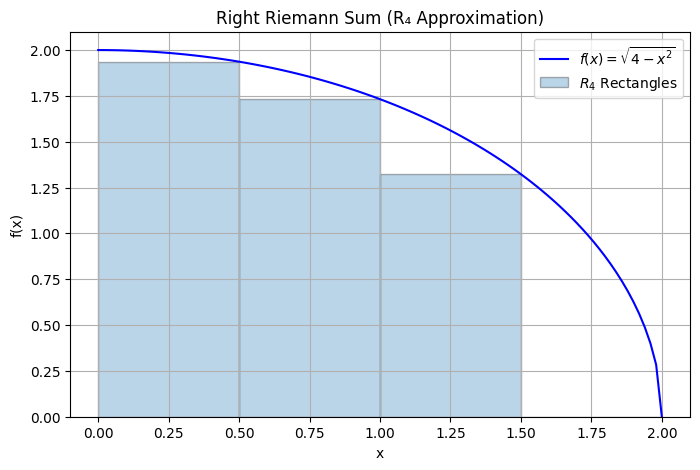

In [9]:
# ---------------------------------------------------------
# PROBLEM A: VISUALIZE FUNCTION + RECTANGLES
# ---------------------------------------------------------
# We will:
# 1. Plot the curve
# 2. Overlay rectangles used in the Riemann sum

a, b, n = 0, 2, 4

# Generate smooth curve values for plotting
x_vals = np.linspace(a, b, 100)
y_vals = f(x_vals)

# Width of each rectangle
delta_x = (b - a) / n

# Right endpoints for rectangles
x_rects = np.linspace(a + delta_x, b, n)

# Heights of rectangles
y_rects = f(x_rects)

# Create plot
plt.figure(figsize=(8, 5))

# Plot the function curve
plt.plot(x_vals, y_vals, 'b-', label='$f(x)=\\sqrt{4-x^2}$')

# Plot rectangles (Riemann sum)
plt.bar(
    x_rects - delta_x,  # shift left so bars start at correct position
    y_rects,
    width=delta_x,
    alpha=0.3,
    align='edge',
    edgecolor='black',
    label='$R_4$ Rectangles'
)

plt.title('Right Riemann Sum (R₄ Approximation)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid()
plt.show()

### **Problem B**
Use the function you created in the previous problem to calculate $R_{4}$.

In [5]:
# ---------------------------------------------------------
# PROBLEM B: CALCULATE R_4
# ---------------------------------------------------------
# Use our function to compute the area with 4 rectangles

r_4 = right_riemann_sum(f, 0, 2, 4)

print(f"R_4 approximation = {r_4:.4f}")

R_4 approximation = 2.4957


### **Problem C**
The area below the curve of a continuous function $f$ on the interval $[a, b]$ can be found by calculating what is called the definite integral of $f$ over $[a, b]$.The definite integral $\int_{a}^{b}f(x)dx$ can be calculated with the following limit:$$\int_{a}^{b}f(x)dx= \text{Area Under the Curve} =\lim_{n\rightarrow\infty}R_{n}$$Calculate appropriate right Riemann sums to find the area under the curve $y=f(x)$ on the interval $[0, 2]$.Does the value of this area have a special name?

**Answer**:
* The function $f(x) = sqrt(4 - x^2)$ represents the upper half of a circle with a radius of 2. On the interval $[0, 2]$, this is exactly a quarter of that circle. The special name for the exact value of this area is $Pi (π)
$, since $(1/4) * π * r^2 = (1/4) * π * 4 = π ≈ 3.14159$.


In [6]:
# ---------------------------------------------------------
# PROBLEM C: APPROXIMATE AREA WITH LARGER n
# ---------------------------------------------------------
# As n increases, rectangles get thinner and the estimate improves.
# This approaches the TRUE area (the definite integral).

n_values = [10, 100, 1000, 10000, 100000]

print("\nApproximating area as n increases:\n")

for n in n_values:
    area_est = right_riemann_sum(f, 0, 2, n)
    print(f"R_{n:<7} = {area_est:.6f}")

print("\nAs n → ∞, the estimate approaches π ≈ 3.141593")


Approximating area as n increases:

R_10      = 2.904518
R_100     = 3.120417
R_1000    = 3.139555
R_10000   = 3.141391
R_100000  = 3.141573

As n → ∞, the estimate approaches π ≈ 3.141593
